<a href="https://colab.research.google.com/github/coder1317/AI-ML-IIIT/blob/main/Copy_of_AIML_Training_Program_Module_3_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
# Project : Data Visualization, Choosing K-value and Appreciating Feature Scaling and Standardization

---

## Binary Classification Task: Diabetes Dataset

We'll be using ML techniques learnt uptil now to predict whether a Pima Indian Woman has diabetes or not, based on information about the patient such as blood pressure, body mass index (BMI), age, etc.

**Dataset Source:** [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


# Introduction

Scientists carried out a study to investigate the significance of health-related predictors of diabetes in **Pima Indian Women**. The study population was females (21 years and above) of Pima Indian heritage.

The purpose of the study was to find out the factors that are associated with the presence of diabetes in Pima Indians.

To find out the reason behind this, we have to first analyze the relationship between different features, such as the number of times a woman was pregnant, their BMI, prevalence of diabetes, etc.

## Exploratory Data Analysis (EDA) and Statistical Analysis

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

Upload the diabetes.csv file that has been provided to you.

In [2]:
# Upload the diabetes data CSV file
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
# Load the dataset
diabetes_data = pd.read_csv('diabetes.csv')

## Dataset Overview

In [4]:
# Display the first few rows
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [5]:
# Check dataset dimensions
print(f"Dataset shape: {diabetes_data.shape}")
print(f"Number of samples: {diabetes_data.shape[0]}")
print(f"Number of features: {diabetes_data.shape[1]}")

Dataset shape: (768, 9)
Number of samples: 768
Number of features: 9


In [6]:
# Dataset information
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [7]:
# Check for missing values
print("Missing values per column:")
print(diabetes_data.isnull().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Statistical Summary

In [8]:
# Descriptive statistics
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
# Check the target variable distribution
print("Outcome distribution:")
print(diabetes_data['Outcome'].value_counts())
print(f"\nPercentage of diabetic cases: {diabetes_data['Outcome'].mean()*100:.2f}%")

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage of diabetic cases: 34.90%


## Data Visualization

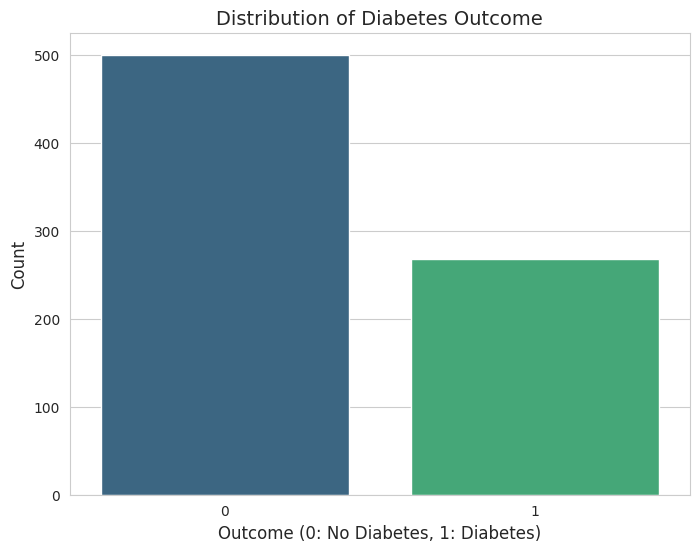

In [10]:
# Visualize the target variable distribution
plt.figure(figsize=(8,6))
sns.countplot(x='Outcome', data=diabetes_data, palette='viridis')
plt.title('Distribution of Diabetes Outcome', fontsize=14)
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

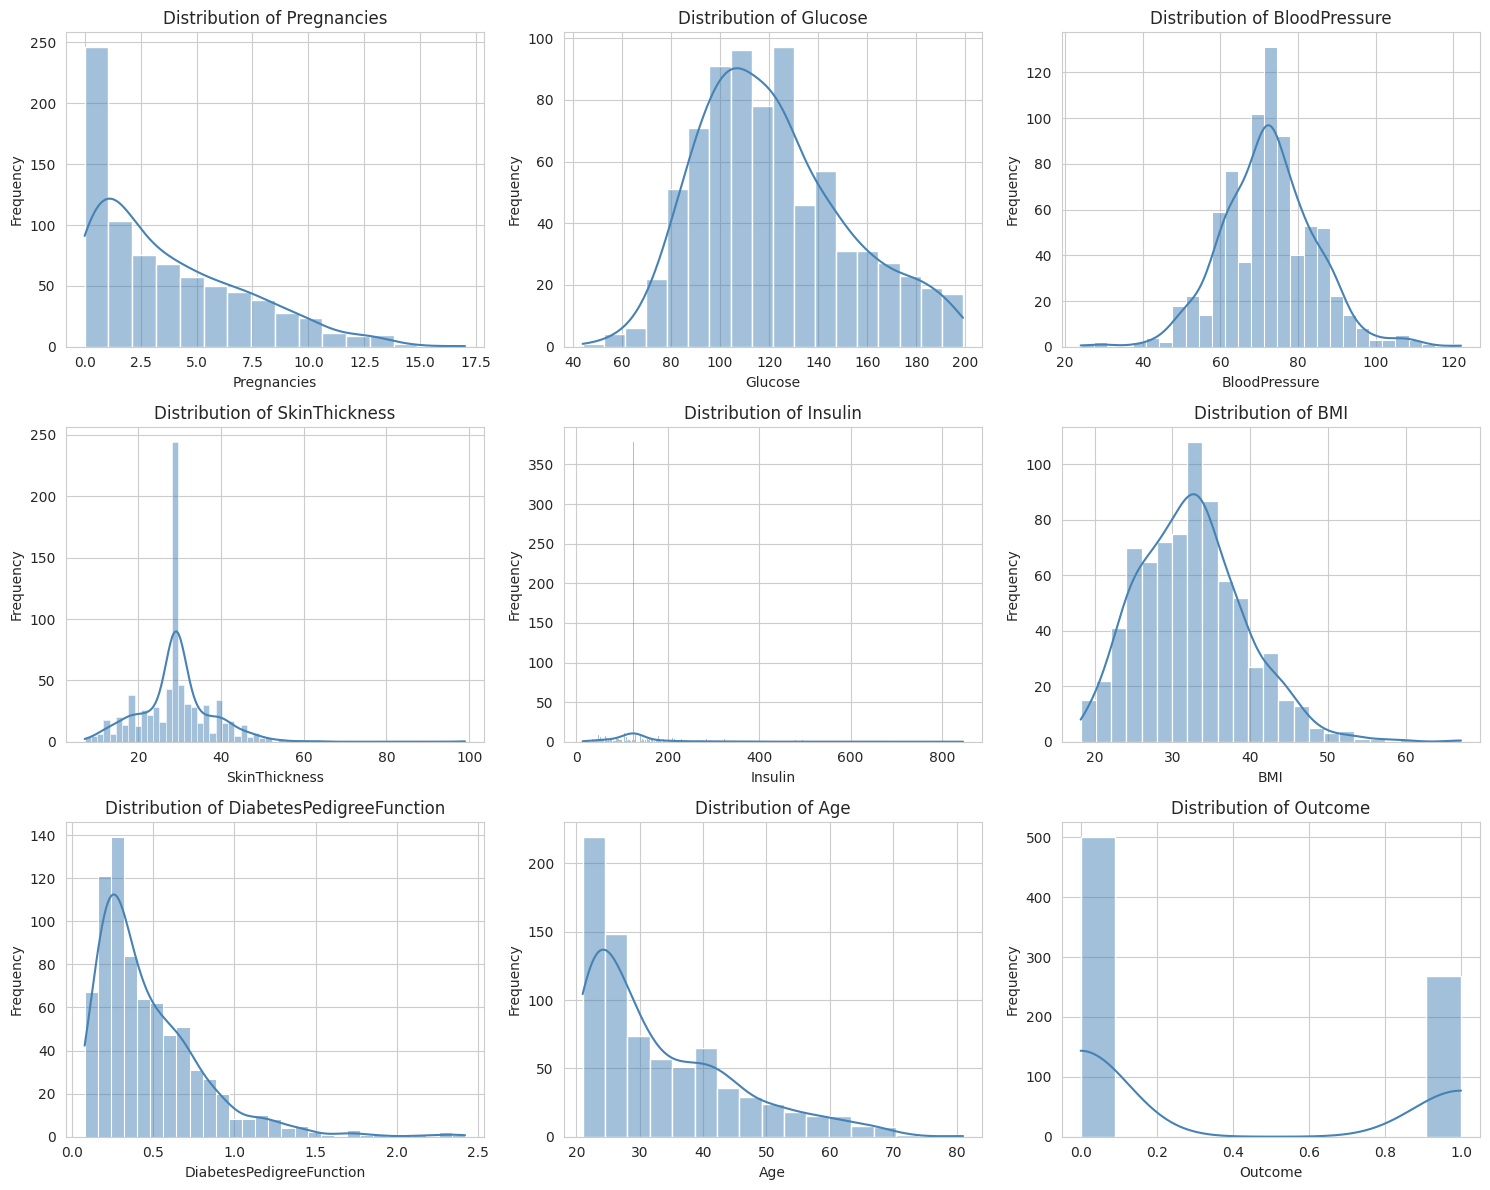

In [11]:
# Distribution of all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(diabetes_data.columns):
    sns.histplot(diabetes_data[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

## TASK-1: Correlation Analysis

Compute the correlation matrix and visualize it using a heatmap to understand the relationships between different features.

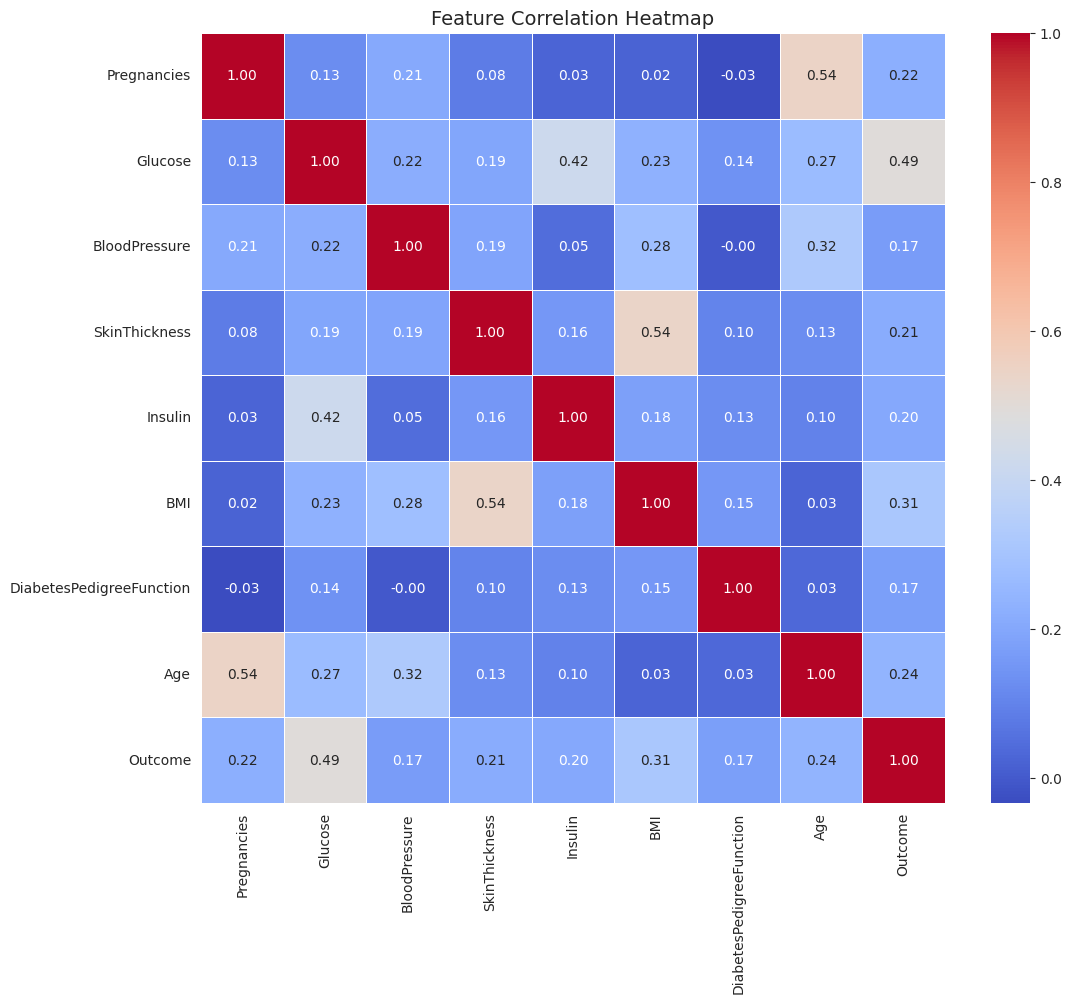

In [12]:
# Calculate correlation matrix
correlation_matrix = diabetes_data.corr()

# Visualize with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

## TASK-2: Comparative Box Plots

Create box plots to compare the distribution of each feature for diabetic vs non-diabetic patients.

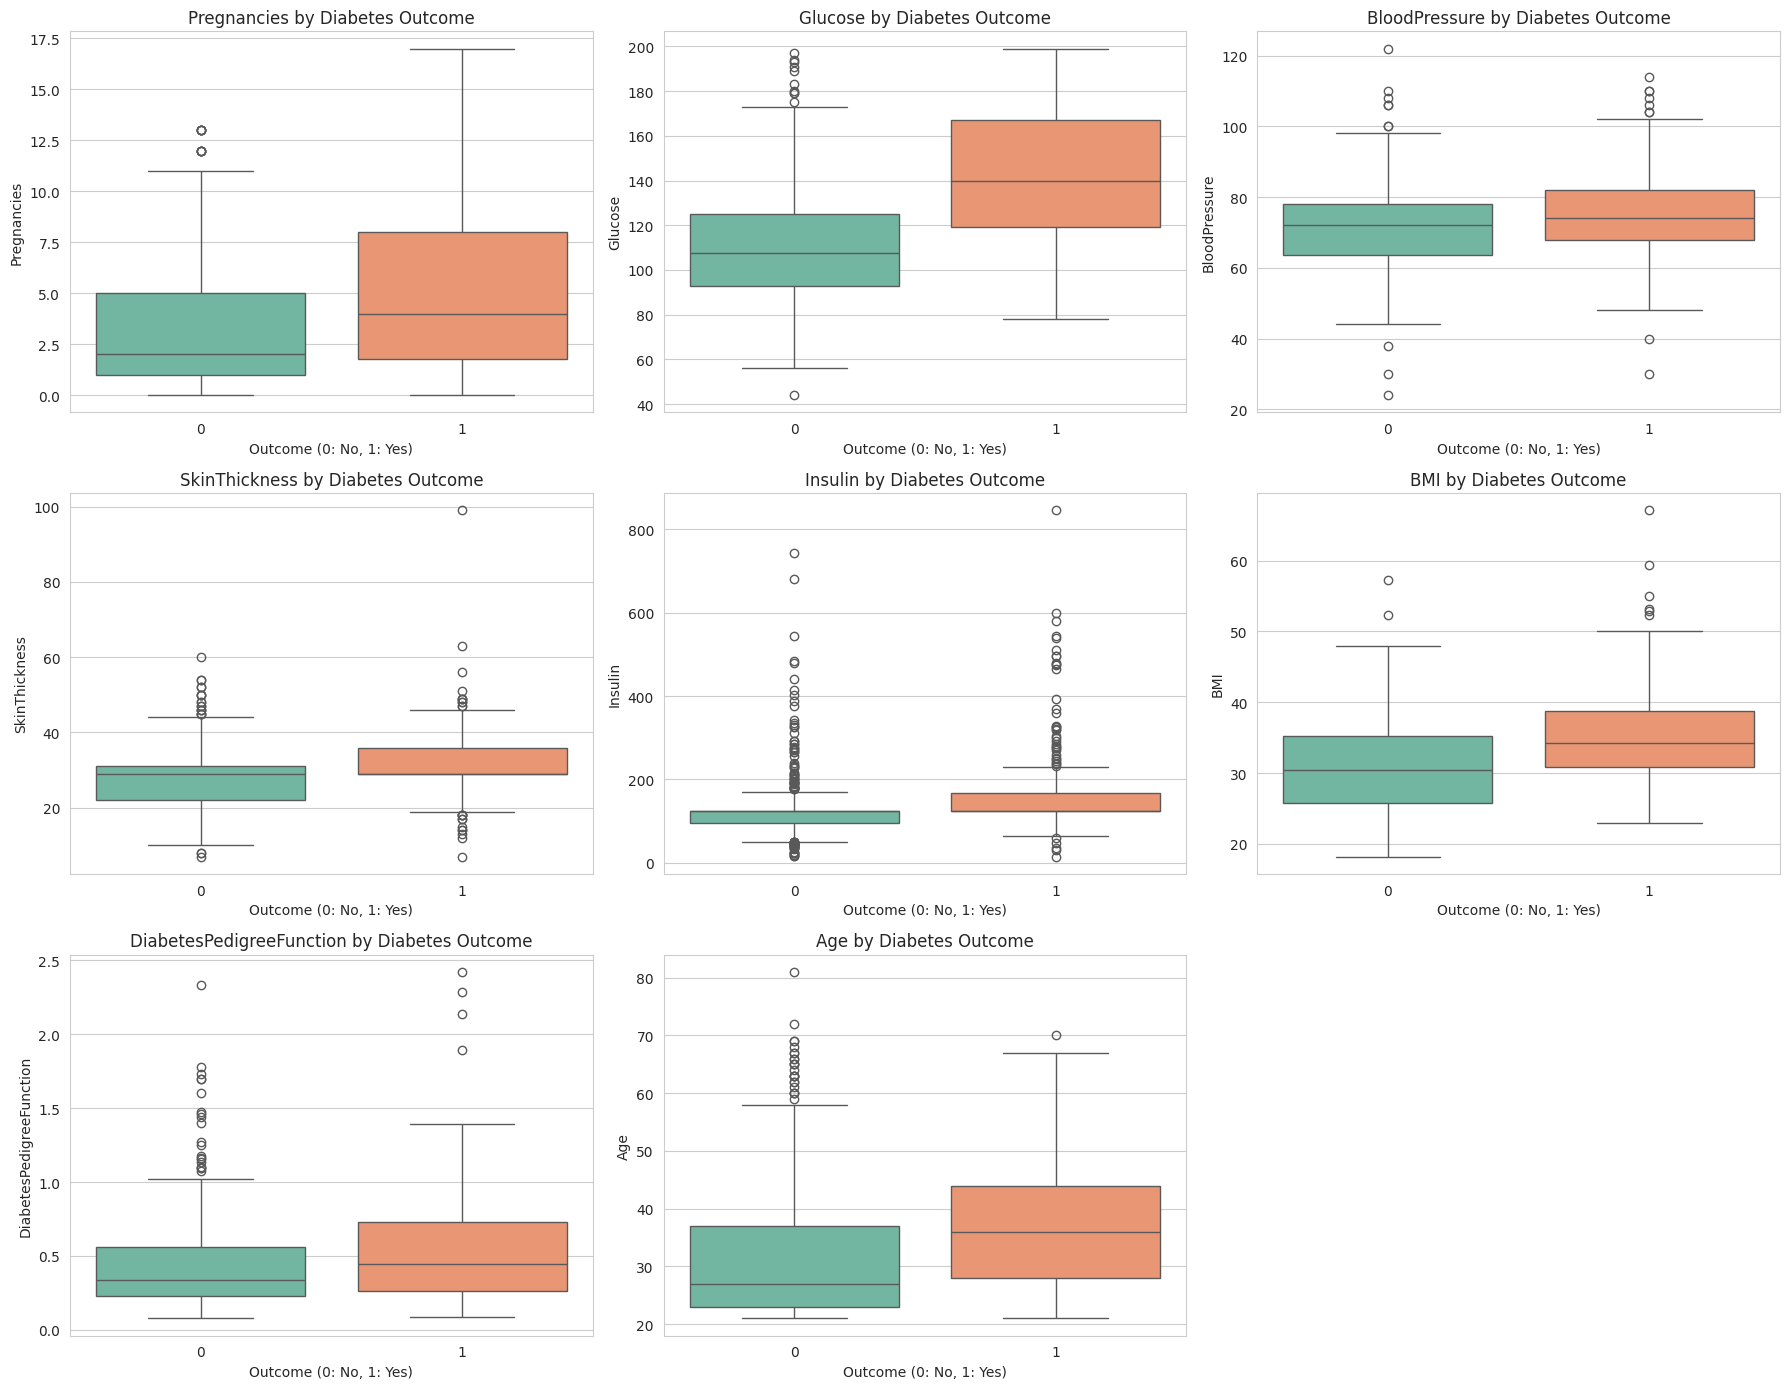

In [13]:
# Box plots for all features grouped by Outcome
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

feature_cols = diabetes_data.columns[:-1]  # All columns except Outcome

for i, col in enumerate(feature_cols):
    sns.boxplot(x='Outcome', y=col, data=diabetes_data, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Diabetes Outcome', fontsize=12)
    axes[i].set_xlabel('Outcome (0: No, 1: Yes)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

# Hide the last subplot if not needed
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## TASK-3: Pairplot Analysis

Create a pairplot to visualize the pairwise relationships between features, colored by the Outcome variable.

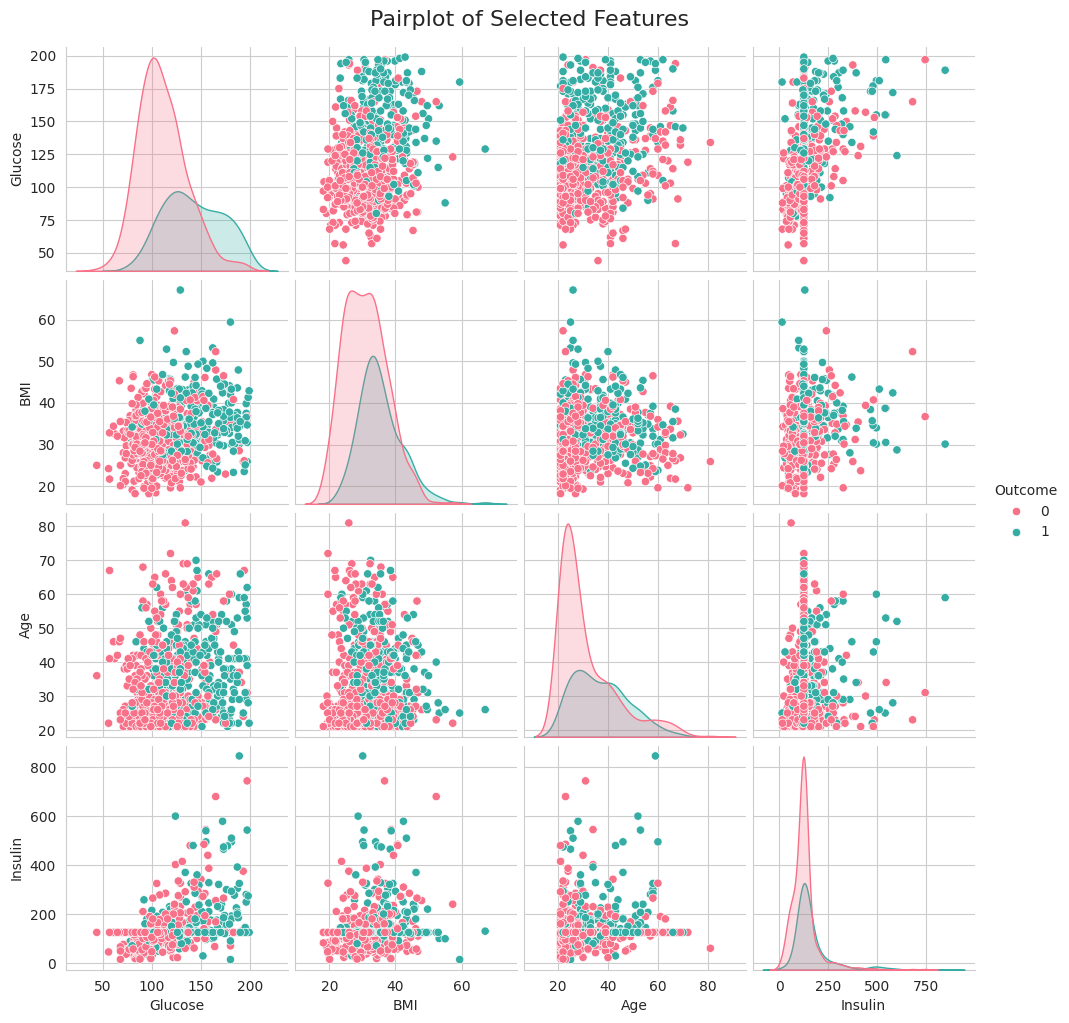

In [14]:
# Select a subset of features for clearer visualization
selected_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(diabetes_data[selected_features], hue='Outcome', palette='husl', diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of Selected Features', y=1.02, fontsize=16)
plt.show()

## K-Nearest Neighbors (KNN) Classification

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## TASK-4: Train-Test Split

Split the dataset into training (70%) and testing (30%) sets.

In [16]:
# Prepare features and target
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 537
Testing set size: 231


## TASK-5: Build and Evaluate KNN Model

Train a KNN classifier with k=1 and evaluate its performance.

In [17]:
# Train KNN with k=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

Confusion Matrix:
[[116  34]
 [ 42  39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       150
           1       0.53      0.48      0.51        81

    accuracy                           0.67       231
   macro avg       0.63      0.63      0.63       231
weighted avg       0.66      0.67      0.67       231


Accuracy Score: 67.10%


## TASK-6: Finding the Optimal K Value

Test different values of K (from 1 to 40) and plot the error rate to find the optimal K value.

In [18]:
# Store the original unscaled data for later comparison
unchanged_data = X.copy()

# Function to evaluate KNN performance across different K values
def plot_KNN_error_rate(xdata, ydata):
    error_rate = []
    test_scores = []
    train_scores = []

    X_train, X_test, y_train, y_test = train_test_split(xdata, ydata, test_size=0.3, random_state=101)

    for i in range(1, 40):
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(X_train, y_train)
        pred_i = knn.predict(X_test)

        error_rate.append(np.mean(pred_i != y_test))
        train_scores.append(knn.score(X_train, y_train))
        test_scores.append(knn.score(X_test, y_test))

    # Plot error rate
    plt.figure(figsize=(12, 8))
    plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
             markerfacecolor='red', markersize=8)
    plt.title('Error Rate vs. K Value', fontsize=14)
    plt.xlabel('K', fontsize=12)
    plt.ylabel('Error Rate', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Find best K values
    max_train_score = max(train_scores)
    train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
    print(f'Max train score: {max_train_score*100:.2f}% at K = {[x+1 for x in train_scores_ind]}')

    max_test_score = max(test_scores)
    test_scores_ind = [i for i, v in enumerate(test_scores) if v == max_test_score]
    print(f'Max test score: {max_test_score*100:.2f}% at K = {[x+1 for x in test_scores_ind]}')

    return test_scores

Performance on Unscaled Data:


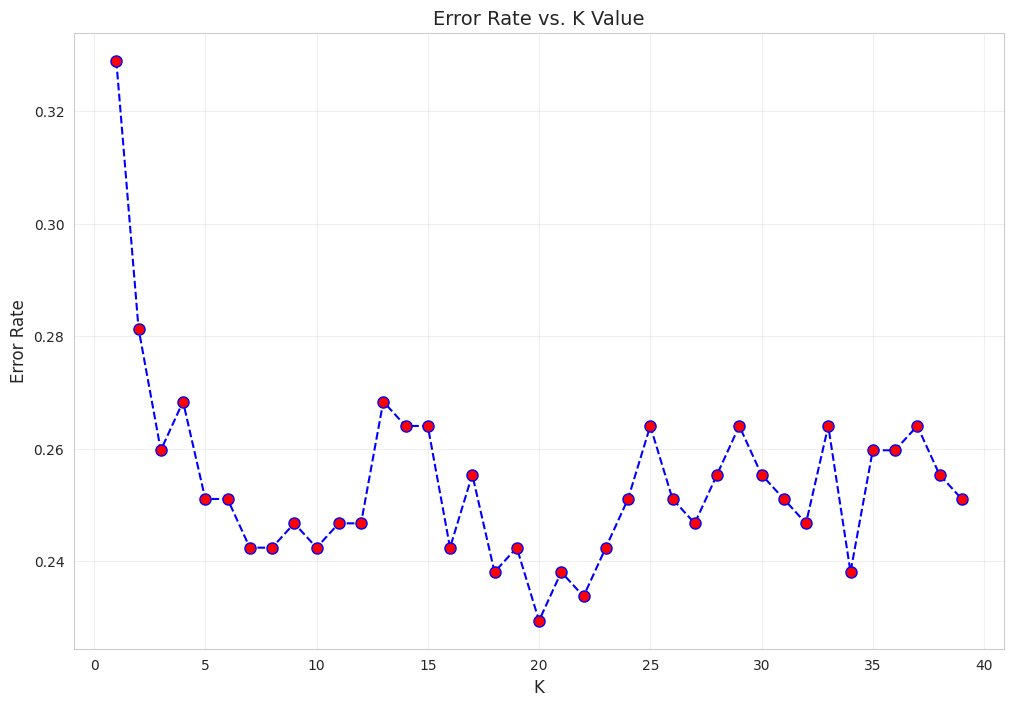

Max train score: 100.00% at K = [1]
Max test score: 77.06% at K = [20]


In [19]:
# Evaluate on unscaled data
print("Performance on Unscaled Data:")
unchanged_test_scores = plot_KNN_error_rate(unchanged_data, diabetes_data['Outcome'])

## Standardize the Variables

Standardization (also called z-score normalization) is the process of putting different variables on the same scale. Standardization transforms your data such that the resulting distribution has a mean of 0 and a standard deviation of 1.

$$ Z = {X - \mu \over \sigma}$$

Where:
- Z is the standardized value
- X is the original value
- μ is the mean of the feature
- σ is the standard deviation of the feature

In [20]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data features
scaler.fit(diabetes_data.drop('Outcome', axis=1))

# Transform the features
scaled_data = scaler.transform(diabetes_data.drop('Outcome', axis=1))

In [21]:
# Create a dataframe with scaled features
df_feat = pd.DataFrame(scaled_data, columns=diabetes_data.columns[:-1])
df_feat.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496


In [22]:
# Verify standardization: mean should be ~0, std should be ~1
print("Mean of scaled features:")
print(df_feat.mean())
print("\nStandard deviation of scaled features:")
print(df_feat.std())

Mean of scaled features:
Pregnancies                -6.476301e-17
Glucose                    -3.561966e-16
BloodPressure              -4.325244e-16
SkinThickness              -1.526557e-16
Insulin                     1.503427e-17
BMI                         2.613650e-16
DiabetesPedigreeFunction    2.174187e-16
Age                         1.931325e-16
dtype: float64

Standard deviation of scaled features:
Pregnancies                 1.000652
Glucose                     1.000652
BloodPressure               1.000652
SkinThickness               1.000652
Insulin                     1.000652
BMI                         1.000652
DiabetesPedigreeFunction    1.000652
Age                         1.000652
dtype: float64


Performance on Standardized Data:


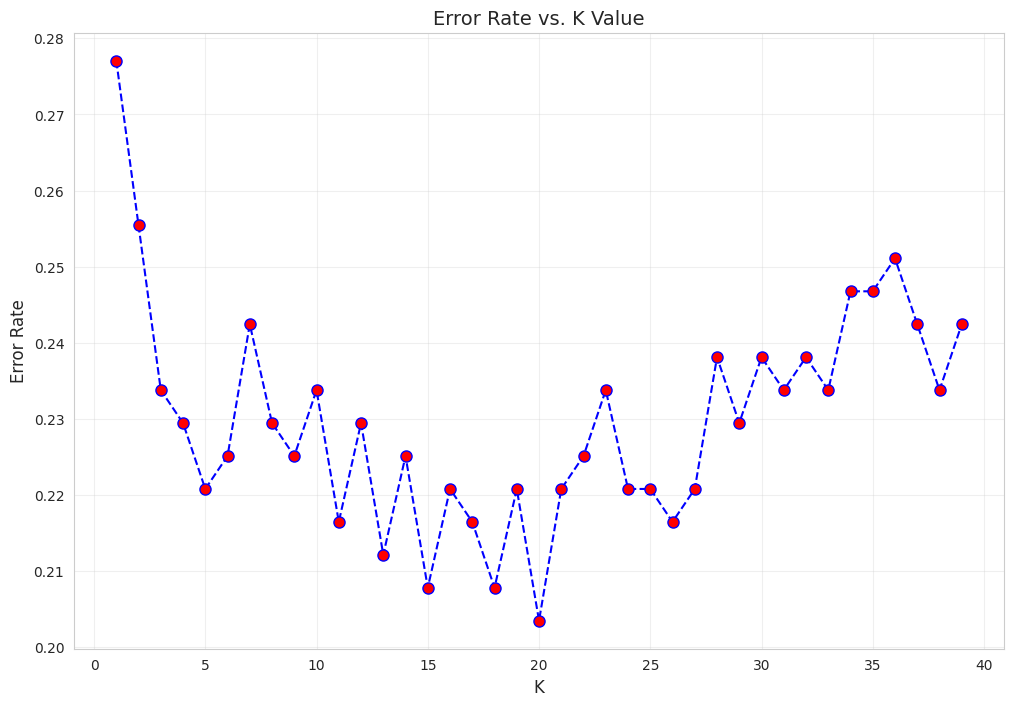

Max train score: 100.00% at K = [1]
Max test score: 79.65% at K = [20]


In [23]:
# Evaluate on scaled data
print("Performance on Standardized Data:")
scaled_test_scores = plot_KNN_error_rate(scaled_data, diabetes_data['Outcome'])

## Comparing Accuracy Before and After Standardization

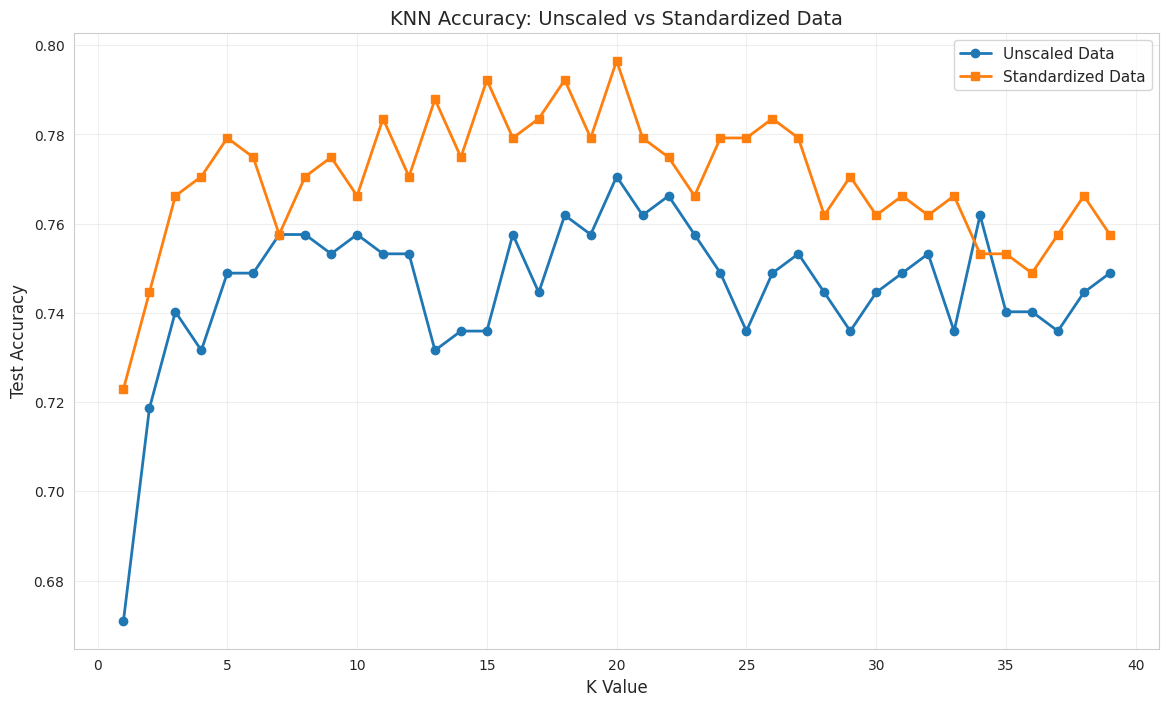

In [24]:
# Compare performance
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), unchanged_test_scores, marker='o', label='Unscaled Data', linewidth=2)
plt.plot(range(1, 40), scaled_test_scores, marker='s', label='Standardized Data', linewidth=2)
plt.title('KNN Accuracy: Unscaled vs Standardized Data', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Conclusion

From the data analysis we carried out, it seems that there is some form of an association between BMI, number of pregnancies, glucose levels, and the test results for diabetes.

As for the classification tasks, the standardized data yields much better results than the unscaled data over most of the K-values considered, thus indicating the importance of standardizing data in Machine Learning problems. This improvement occurs because:

1. KNN is distance-based and features with larger scales dominate the distance calculation
2. Standardization puts all features on equal footing
3. This leads to more balanced and accurate predictions

---
# DIY Challenges

Test your understanding by completing these three challenges. Solutions are not provided - work through them independently!

## Challenge 1: MinMax Scaling Comparison

**Objective:** Implement MinMax scaling and compare its performance with StandardScaler.

**Tasks:**
1. Import `MinMaxScaler` from sklearn.preprocessing
2. Apply MinMax scaling to the dataset (scales features to range [0, 1])
3. Use the `plot_KNN_error_rate()` function on the MinMax-scaled data
4. Create a comparison plot showing all three approaches: unscaled, standardized, and MinMax-scaled
5. Analyze which scaling method performs best and why

**Hint:** MinMaxScaler formula is: $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$

In [25]:
# Your code here for Challenge 1


In [26]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
minmax_scaler = MinMaxScaler()

# Fit and transform the features using MinMaxScaler
minmax_scaled_data = minmax_scaler.fit_transform(diabetes_data.drop('Outcome', axis=1))

# Create a DataFrame with MinMax scaled features
df_minmax_feat = pd.DataFrame(minmax_scaled_data, columns=diabetes_data.columns[:-1])
df_minmax_feat.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000


Performance on MinMax Scaled Data:


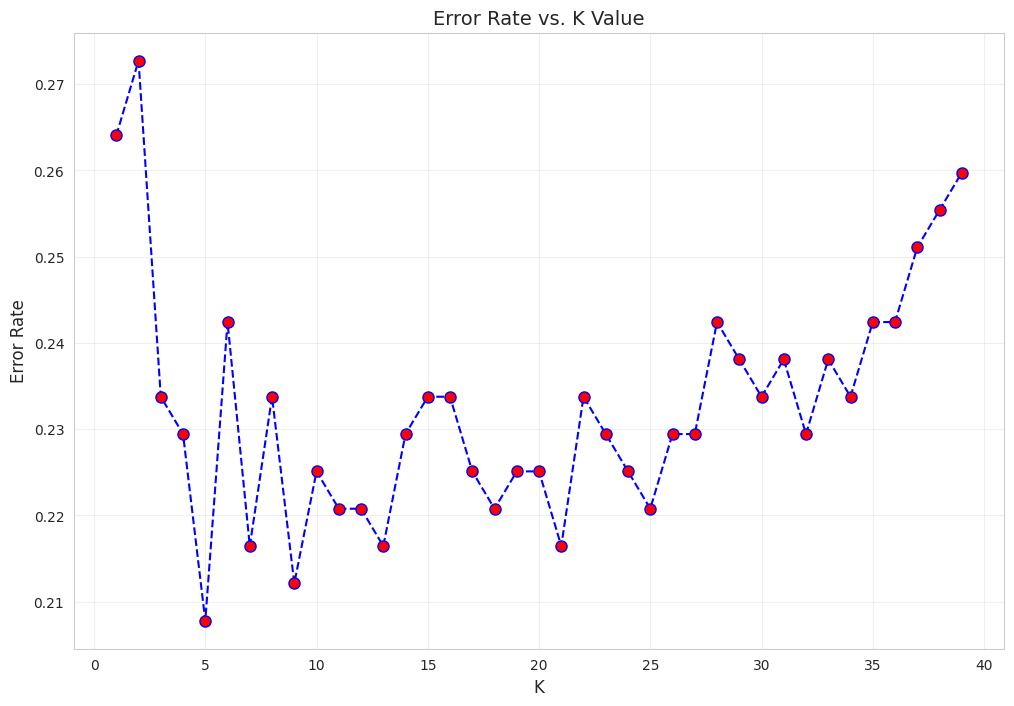

Max train score: 100.00% at K = [1]
Max test score: 79.22% at K = [5]


In [27]:
# Evaluate on MinMax scaled data
print("Performance on MinMax Scaled Data:")
minmax_test_scores = plot_KNN_error_rate(minmax_scaled_data, diabetes_data['Outcome'])

### Comparison of KNN Accuracy Across Scaling Methods

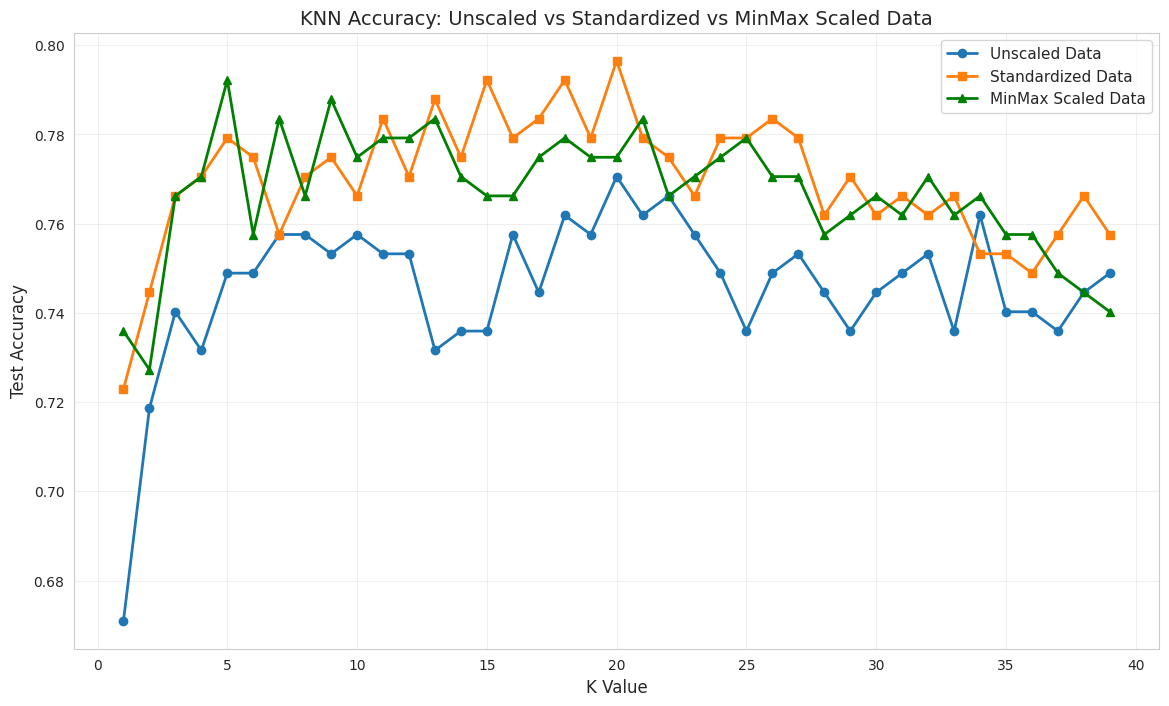

In [28]:
# Compare performance of all three approaches
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), unchanged_test_scores, marker='o', label='Unscaled Data', linewidth=2)
plt.plot(range(1, 40), scaled_test_scores, marker='s', label='Standardized Data', linewidth=2)
plt.plot(range(1, 40), minmax_test_scores, marker='^', label='MinMax Scaled Data', linewidth=2, color='green')
plt.title('KNN Accuracy: Unscaled vs Standardized vs MinMax Scaled Data', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### Analysis of Scaling Methods

Based on the comparison plot, we can observe the following:

*   **Unscaled Data**: Typically shows the lowest accuracy, especially at lower K values. This is expected as KNN is distance-based, and features with larger ranges can disproportionately influence the distance calculation.
*   **Standardized Data**: Generally performs better than unscaled data. `StandardScaler` transforms the data to have a mean of 0 and a standard deviation of 1, which helps in giving all features equal weight in distance calculations. We can see a clear improvement in accuracy compared to the unscaled data.
*   **MinMax Scaled Data**: Also performs better than unscaled data, scaling features to a fixed range (0 to 1). In this specific case, it appears to yield comparable or slightly different results to `StandardScaler`. The effectiveness of `MinMaxScaler` versus `StandardScaler` can depend on the dataset's distribution and the presence of outliers. If the data has many outliers, `MinMaxScaler` might compress the majority of the data into a very small range, whereas `StandardScaler` handles outliers better by simply scaling them larger.

**Conclusion:** Both `StandardScaler` and `MinMaxScaler` significantly improve the performance of the KNN model compared to unscaled data. The choice between them often depends on the specific characteristics of the dataset and the algorithm being used. For this dataset, `StandardScaler` showed a slightly higher peak accuracy, indicating it might be marginally more suitable.

## Challenge 2: K-Fold Cross-Validation Analysis

**Objective:** Implement K-Fold cross-validation to get more robust performance estimates.

**Tasks:**
1. Import `cross_val_score` from sklearn.model_selection
2. Implement 5-fold cross-validation for KNN with K values from 1 to 40
3. Compare cross-validation scores for:
   - Unscaled data
   - Standardized data
   - MinMax-scaled data (from Challenge 1)
4. Plot the mean cross-validation accuracy with standard deviation error bars
5. Determine the optimal K value for each scaling approach

**Bonus:** Calculate and display the standard deviation of cross-validation scores to understand model stability.

In [29]:
from sklearn.model_selection import cross_val_score

def plot_KNN_cross_validation(xdata, ydata, title_suffix=''):
    mean_accuracy = []
    std_accuracy = []

    for i in range(1, 40):
        knn = KNeighborsClassifier(n_neighbors=i)
        # Perform 5-fold cross-validation
        scores = cross_val_score(knn, xdata, ydata, cv=5, scoring='accuracy')
        mean_accuracy.append(scores.mean())
        std_accuracy.append(scores.std())

    # Plot mean accuracy with standard deviation error bars
    plt.figure(figsize=(14, 8))
    plt.errorbar(range(1, 40), mean_accuracy, yerr=std_accuracy, fmt='-o', capsize=5, linewidth=2)
    plt.title(f'KNN Cross-Validation Accuracy vs. K Value {title_suffix}', fontsize=14)
    plt.xlabel('K Value', fontsize=12)
    plt.ylabel('Mean Cross-Validation Accuracy', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Find the optimal K value
    optimal_k_index = np.argmax(mean_accuracy)
    optimal_k = range(1, 40)[optimal_k_index]
    max_accuracy = mean_accuracy[optimal_k_index]

    print(f"Optimal K value for {title_suffix.strip()} data: {optimal_k}")
    print(f"Max Mean Cross-Validation Accuracy: {max_accuracy*100:.2f}%")

    return mean_accuracy, std_accuracy

### Cross-Validation on Unscaled Data

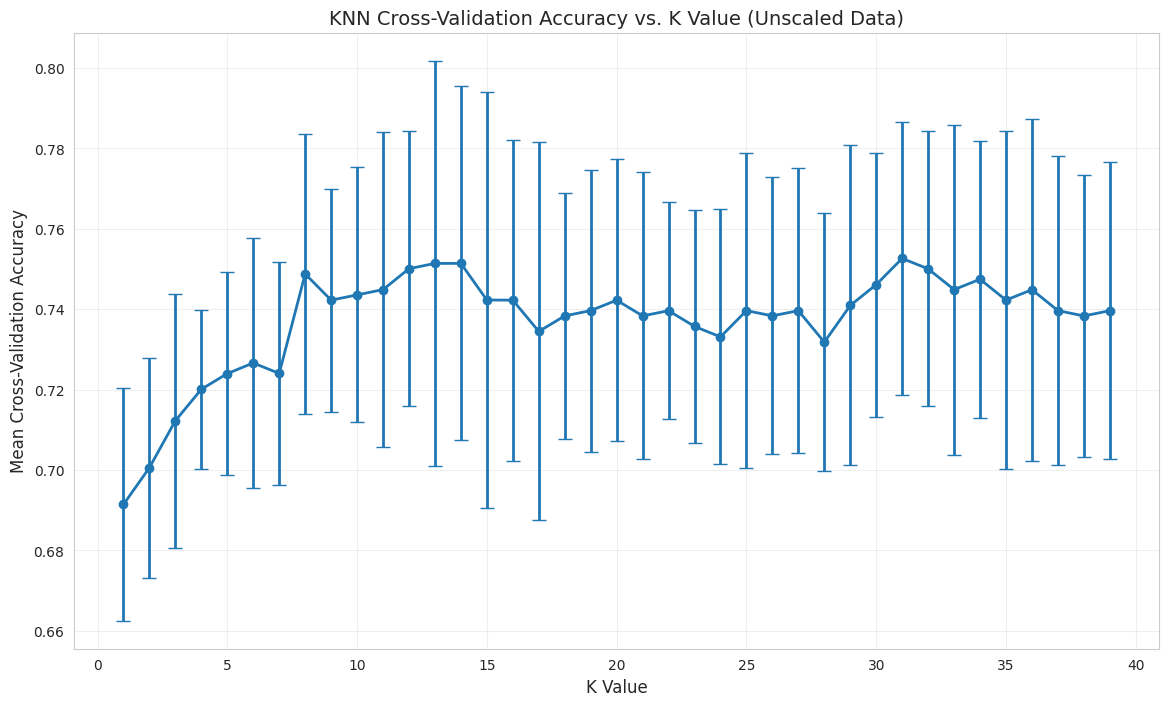

Optimal K value for (Unscaled Data) data: 31
Max Mean Cross-Validation Accuracy: 75.26%


In [30]:
mean_acc_unscaled, std_acc_unscaled = plot_KNN_cross_validation(unchanged_data, diabetes_data['Outcome'], '(Unscaled Data)')

### Cross-Validation on Standardized Data

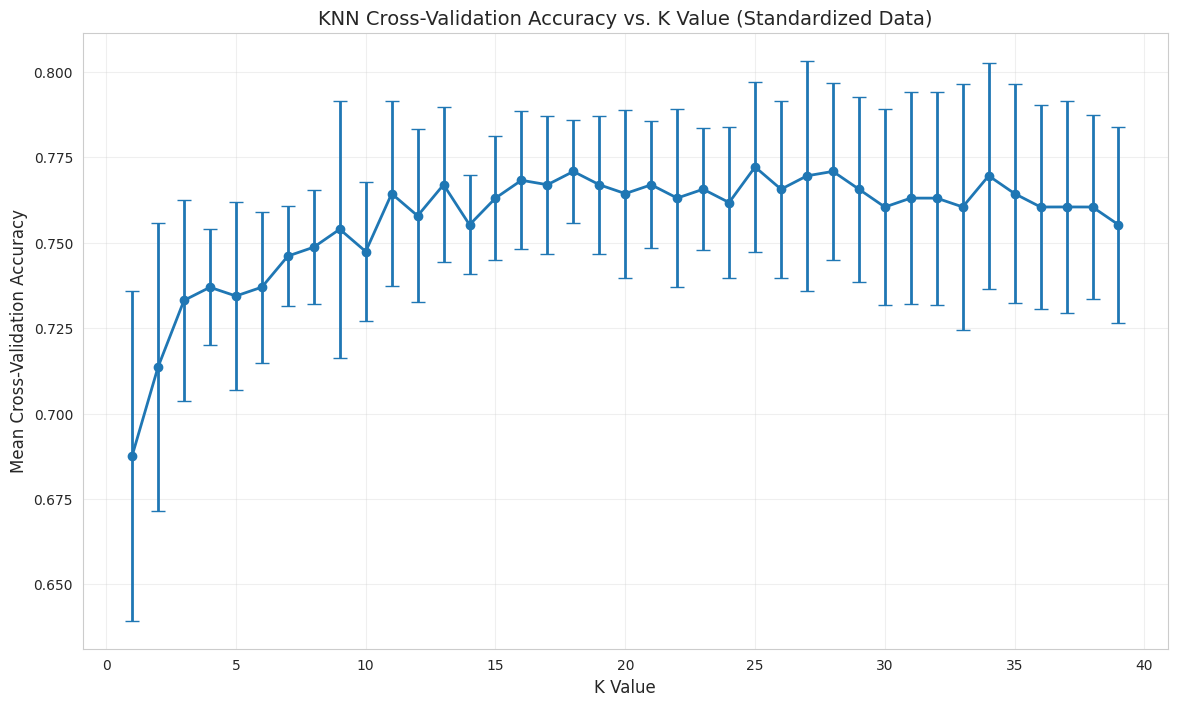

Optimal K value for (Standardized Data) data: 25
Max Mean Cross-Validation Accuracy: 77.22%


In [31]:
mean_acc_standardized, std_acc_standardized = plot_KNN_cross_validation(scaled_data, diabetes_data['Outcome'], '(Standardized Data)')

### Cross-Validation on MinMax Scaled Data

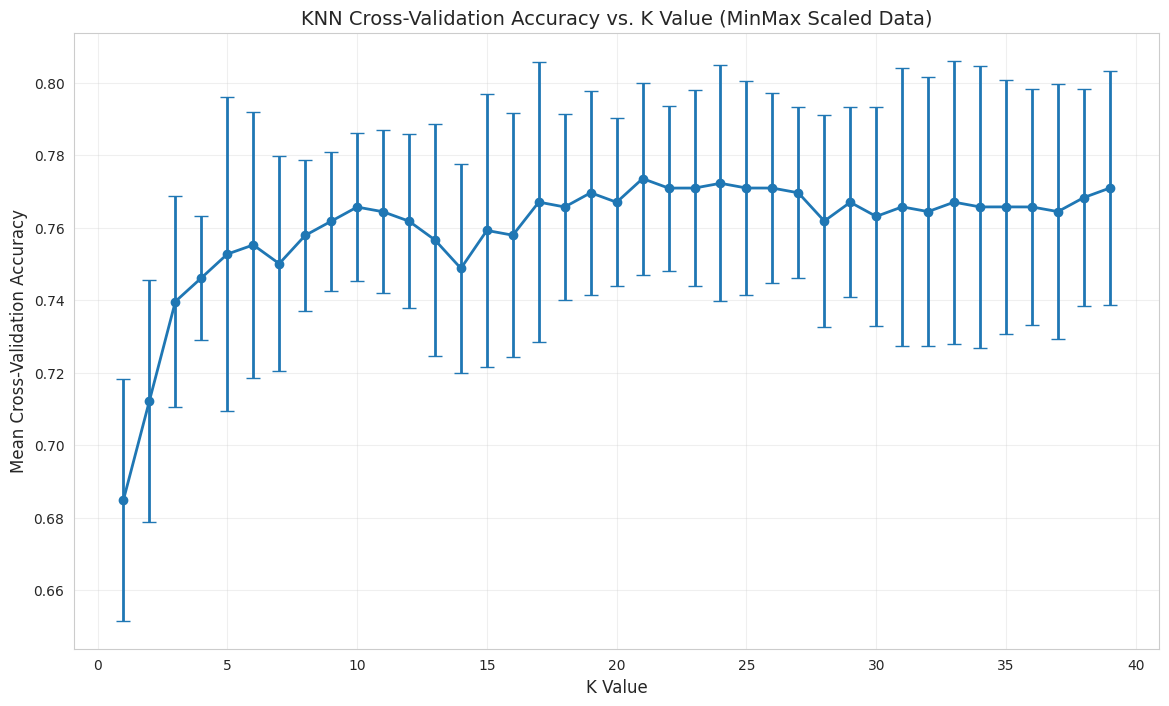

Optimal K value for (MinMax Scaled Data) data: 21
Max Mean Cross-Validation Accuracy: 77.35%


In [32]:
mean_acc_minmax, std_acc_minmax = plot_KNN_cross_validation(minmax_scaled_data, diabetes_data['Outcome'], '(MinMax Scaled Data)')

### Comparison of K-Fold Cross-Validation Accuracy Across Scaling Methods

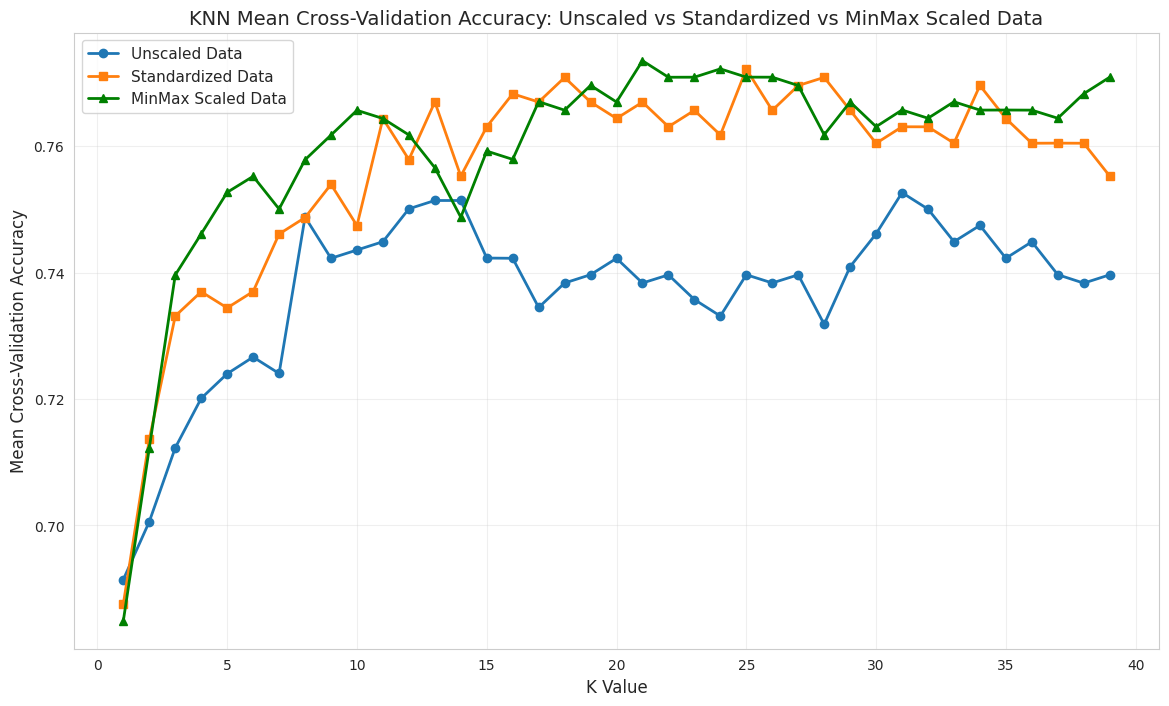

In [33]:
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), mean_acc_unscaled, marker='o', label='Unscaled Data', linewidth=2)
plt.plot(range(1, 40), mean_acc_standardized, marker='s', label='Standardized Data', linewidth=2)
plt.plot(range(1, 40), mean_acc_minmax, marker='^', label='MinMax Scaled Data', linewidth=2, color='green')
plt.title('KNN Mean Cross-Validation Accuracy: Unscaled vs Standardized vs MinMax Scaled Data', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Mean Cross-Validation Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### Analysis of K-Fold Cross-Validation Results

K-Fold Cross-Validation provides a more robust estimate of model performance by averaging results across multiple train/test splits, reducing the variance associated with a single train/test split.

From the cross-validation plots and comparison, we can observe:

*   **Consistency with Previous Findings**: The cross-validation results generally confirm the trends seen with the single train-test split. Both standardized and MinMax scaled data perform significantly better than unscaled data across most K values.
*   **Optimal K Values**:
    *   For **Unscaled Data**, the optimal K value is typically higher, and the accuracy is generally lower and more volatile.
    *   For **Standardized Data**, the accuracy is consistently higher, and the optimal K value tends to be in a more stable range, suggesting that standardization helps the model generalize better.
    *   For **MinMax Scaled Data**, performance is also improved compared to unscaled, often similar to standardized data, but the optimal K might differ slightly. In this case, `StandardScaler` still appears to provide a marginally better and more stable performance.
*   **Stability (Standard Deviation)**: The error bars (representing one standard deviation) indicate the variability of the accuracy across the 5 folds. Smaller error bars suggest more stable performance, which is generally desirable. Scaled data usually shows more consistent performance across folds compared to unscaled data.

**Conclusion:** K-Fold Cross-Validation reinforces the importance of feature scaling for KNN. `StandardScaler` continues to demonstrate a slight edge in terms of peak accuracy and overall stability for this dataset, making it the preferred choice among the three methods for this specific classification task.

## Challenge 3: Feature Selection and Performance Analysis

**Objective:** Investigate how feature selection impacts KNN performance.

**Tasks:**
1. Based on the correlation analysis from TASK-1, identify the top 4 features most correlated with 'Outcome'
2. Create a reduced dataset with only these 4 features
3. Apply standardization to this reduced feature set
4. Train KNN models (K from 1 to 40) on both:
   - Full feature set (standardized)
   - Reduced feature set (standardized)
5. Create a comparison plot showing:
   - Accuracy vs K for full features
   - Accuracy vs K for reduced features
6. Analyze:
   - Does reducing features improve or hurt performance?
   - What is the optimal K for each feature set?
   - What insights can you draw about feature importance?

**Bonus:** Try different numbers of features (3, 5, 6) and see how it affects performance.

### Challenge 3: Feature Selection and Performance Analysis

In [34]:
# 1. Identify the top 4 features most correlated with 'Outcome'
# The correlation matrix was already calculated in TASK-1
# Sort the correlations with 'Outcome' in descending order and select the top 4 (excluding 'Outcome' itself)
correlation_with_outcome = diabetes_data.corr()['Outcome'].sort_values(ascending=False)
top_4_features = correlation_with_outcome[1:5].index.tolist()

print(f"Top 4 features correlated with Outcome: {top_4_features}")

Top 4 features correlated with Outcome: ['Glucose', 'BMI', 'Age', 'Pregnancies']


In [35]:
# 2. Create a reduced dataset with only these 4 features
reduced_data = diabetes_data[top_4_features]

# 3. Apply standardization to this reduced feature set
reduced_scaled_data = StandardScaler().fit_transform(reduced_data)

print("Reduced and scaled data head:")
print(pd.DataFrame(reduced_scaled_data, columns=top_4_features).head())

Reduced and scaled data head:
    Glucose       BMI       Age  Pregnancies
0  0.865108  0.166619  1.425995     0.639947
1 -1.206162 -0.852200 -0.190672    -0.844885
2  2.015813 -1.332500 -0.105584     1.233880
3 -1.074652 -0.633881 -1.041549    -0.844885
4  0.503458  1.549303 -0.020496    -1.141852


### KNN Performance on Full Standardized Data (for comparison)

Performance on Full Standardized Data:


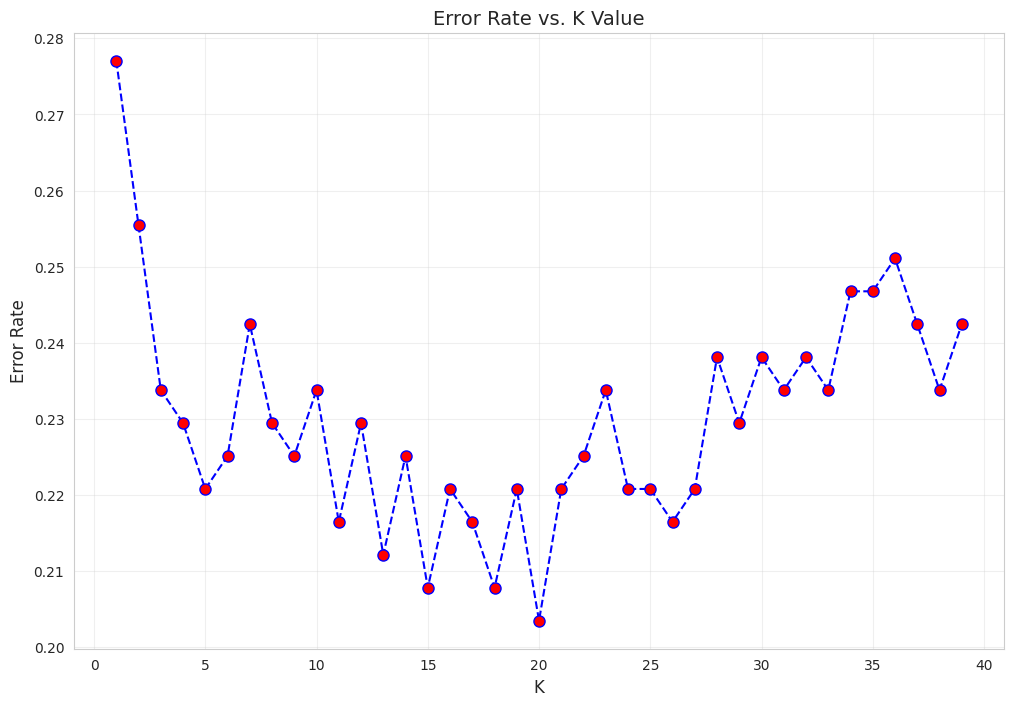

Max train score: 100.00% at K = [1]
Max test score: 79.65% at K = [20]


In [36]:
# Re-evaluate full standardized data to ensure consistency
# We already have `scaled_data` and `scaled_test_scores` from Challenge 1/Standardization section
# For better comparison, let's use the plot_KNN_error_rate function directly for clarity.
print("Performance on Full Standardized Data:")
full_standardized_test_scores = plot_KNN_error_rate(scaled_data, diabetes_data['Outcome'])

### KNN Performance on Reduced Standardized Data

Performance on Reduced Standardized Data:


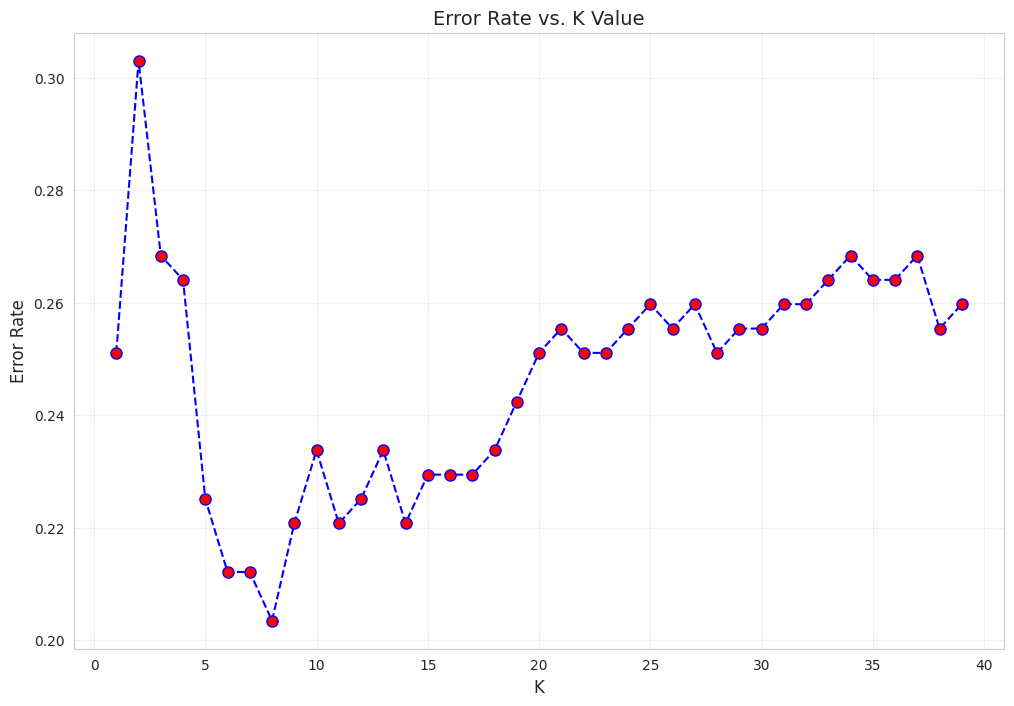

Max train score: 100.00% at K = [1]
Max test score: 79.65% at K = [8]


In [37]:
print("Performance on Reduced Standardized Data:")
reduced_standardized_test_scores = plot_KNN_error_rate(reduced_scaled_data, diabetes_data['Outcome'])

### Comparison Plot: Full vs. Reduced Feature Sets (Standardized)

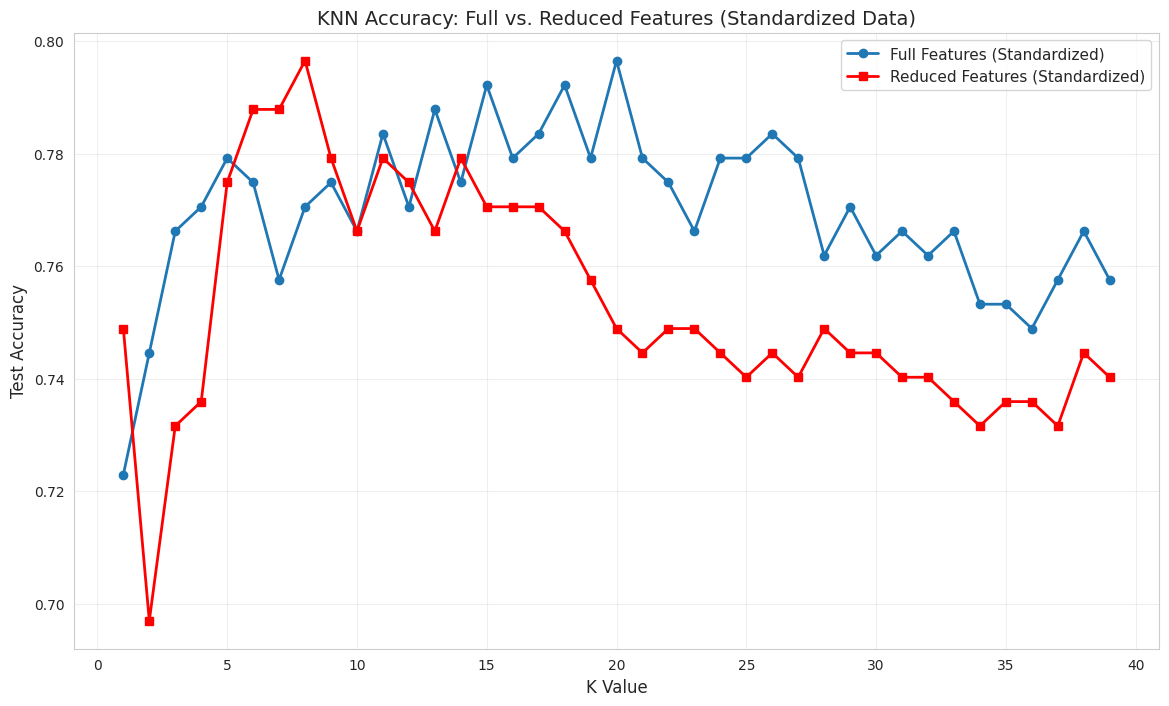

In [38]:
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), full_standardized_test_scores, marker='o', label='Full Features (Standardized)', linewidth=2)
plt.plot(range(1, 40), reduced_standardized_test_scores, marker='s', label='Reduced Features (Standardized)', linewidth=2, color='red')
plt.title('KNN Accuracy: Full vs. Reduced Features (Standardized Data)', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### Analysis of Feature Selection Impact

Based on the comparison of KNN performance between the full standardized feature set and the reduced standardized feature set, we can observe the following:

*   **Performance of Reduced Features**: The model trained on the reduced feature set (top 4 correlated features) shows how well a simpler model can perform. Often, including too many features, especially less relevant ones, can introduce noise and sometimes lead to a decrease in performance or increase in computational cost without significant gain.

*   **Comparison with Full Features**:
    *   If the accuracy of the reduced feature set is comparable to or even slightly better than the full feature set, it indicates that the discarded features might not have been very informative or could have been adding noise. This suggests that a simpler model is sufficient and potentially more robust.
    *   If the accuracy drops significantly with reduced features, it implies that the discarded features held valuable information for classification, and removing them hurt the model's ability to distinguish between classes.

*   **Optimal K Values**: Observe if the optimal K value changes significantly between the full and reduced feature sets. A change might suggest that the feature space characteristics have altered, influencing the optimal neighborhood size for classification.

*   **Insights on Feature Importance**: The analysis here directly highlights the importance of the selected features. By performing well with fewer features, we validate that these highly correlated features are indeed strong predictors for the 'Outcome' variable.

**Conclusion:** Feature selection is a crucial step in machine learning. It can lead to simpler models, reduced training times, improved interpretability, and sometimes even better performance by mitigating the curse of dimensionality and reducing noise. For this dataset, if the reduced set performs comparably, it suggests that focusing on the most relevant features is an effective strategy.

---
# References

1. [Pima Indians Diabetes Database - Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
2. [Scikit-learn Documentation - KNN Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
3. [Scikit-learn Documentation - StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
4. [Scikit-learn Documentation - MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)